# Fast R-CNN — Huấn luyện phát hiện mũ bảo hiểm
**Môi trường:** Jupyter local | **Dataset:** dataset_coco_cropped | **Backbone:** ResNet-50 FPN

> Metrics: Precision / Recall / F1 / **Mean IoU**

## 1. Kiểm tra thư viện

In [2]:
# Bo comment neu chua cai:
# !pip install torch torchvision pycocotools albumentations opencv-contrib-python pandas
import torch, torchvision, cv2, albumentations
print('torch       :', torch.__version__)
print('torchvision :', torchvision.__version__)
print('opencv      :', cv2.__version__)
print('albumentations:', albumentations.__version__)

torch       : 2.11.0+cu126
torchvision : 0.26.0+cu126
opencv      : 4.13.0
albumentations: 2.0.8


## 2. Import

In [3]:
import torch
import os, time, csv, pickle, random
from collections import OrderedDict

from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models import ResNet50_Weights
from torchvision.ops import MultiScaleRoIAlign
from torchvision.models.detection.roi_heads import RoIHeads
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torch.utils.data import Dataset, DataLoader
from pycocotools.coco import COCO
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np
import cv2
import torch.nn as nn
import torch.nn.functional as TF
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device  :', device)
print('PyTorch :', torch.__version__)
print('CUDA    :', torch.version.cuda if torch.cuda.is_available() else 'N/A')
if torch.cuda.is_available():
    print('GPU     :', torch.cuda.get_device_name(0))
    vram = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
    print('VRAM    :', vram, 'GB')

Device  : cuda
PyTorch : 2.11.0+cu126
CUDA    : 12.6
GPU     : NVIDIA GeForce RTX 4090
VRAM    : 23.6 GB


## 3. Cấu hình đường dẫn và hyperparameter

In [4]:
# ===== PATHS =====
BASE_DIR    = os.getcwd()
DATASET_DIR = os.path.normpath(os.path.join(BASE_DIR, '..', 'workspace', 'dataset_coco_cropped'))

TRAIN_IMG = os.path.join(DATASET_DIR, 'train', 'images')
TRAIN_ANN = os.path.join(DATASET_DIR, 'train', '_annotations.coco.json')
VALID_IMG = os.path.join(DATASET_DIR, 'valid', 'images')
VALID_ANN = os.path.join(DATASET_DIR, 'valid', '_annotations.coco.json')

TRAIN_SS_CACHE = os.path.join(DATASET_DIR, 'train_ss_proposals.pkl')
VALID_SS_CACHE = os.path.join(DATASET_DIR, 'valid_ss_proposals.pkl')

OUTPUT_DIR = os.path.join(BASE_DIR, 'fast_rcnn_output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ===== HYPERPARAMETERS =====
NUM_EPOCHS                = 30
BATCH_SIZE                = 2
LR_HEAD                   = 9.97e-03
LR_BACKBONE               = 5.76e-04
MOMENTUM                  = 0.9
WEIGHT_DECAY              = 2.22e-04
DROPOUT_RATE              = 0.304
GRAD_CLIP_NORM            = 5.0
EARLY_STOPPING_PATIENCE   = 10
MIN_DELTA                 = 1e-4
TRAINABLE_BACKBONE_LAYERS = 3
MAX_PROPOSALS_TRAIN       = 2000
MAX_PROPOSALS_EVAL        = 2000
NUM_WORKERS               = 0 if os.name == 'nt' else 4

# Kiem tra duong dan
print('===== PATHS =====')
for name, p in [('DATASET_DIR', DATASET_DIR), ('TRAIN_IMG', TRAIN_IMG),
                ('TRAIN_ANN', TRAIN_ANN), ('VALID_IMG', VALID_IMG),
                ('VALID_ANN', VALID_ANN), ('OUTPUT_DIR', OUTPUT_DIR)]:
    status = 'OK' if os.path.exists(p) else 'KHONG TIM THAY'
    print(f'  {status:15}  {name}')

print('===== HYPERPARAMETERS =====')
print(f'  Epochs:          {NUM_EPOCHS}')
print(f'  Batch size:      {BATCH_SIZE}')
print(f'  LR head:         {LR_HEAD}  |  backbone: {LR_BACKBONE}')
print(f'  Weight decay:    {WEIGHT_DECAY}  |  Dropout: {DROPOUT_RATE}')
print(f'  Backbone layers: {TRAINABLE_BACKBONE_LAYERS}')
print(f'  Patience:        {EARLY_STOPPING_PATIENCE}')
print(f'  Max proposals:   {MAX_PROPOSALS_TRAIN} (train) | {MAX_PROPOSALS_EVAL} (eval)')
print(f'  Num workers:     {NUM_WORKERS}')
print(f'  Output dir:      {OUTPUT_DIR}')

===== PATHS =====
  OK               DATASET_DIR
  OK               TRAIN_IMG
  OK               TRAIN_ANN
  OK               VALID_IMG
  OK               VALID_ANN
  OK               OUTPUT_DIR
===== HYPERPARAMETERS =====
  Epochs:          30
  Batch size:      2
  LR head:         0.00997  |  backbone: 0.000576
  Weight decay:    0.000222  |  Dropout: 0.304
  Backbone layers: 3
  Patience:        10
  Max proposals:   2000 (train) | 2000 (eval)
  Num workers:     4
  Output dir:      /workspace/fast_rcnn_output


## 4. Pre-compute Selective Search Proposals

In [5]:
import multiprocessing
from tqdm.notebook import tqdm

# ==============================================================================
# 1. HÀM WORKER XỬ LÝ 1 ẢNH (BẮT BUỘC ĐỂ NGOÀI CÙNG ĐỂ CHẠY ĐA LUỒNG)
# ==============================================================================
def process_single_image_optimized(args):
    """
    Worker function: Đọc ảnh, thu nhỏ, chạy SS Fast, trả về [img_id, boxes].
    """
    img_id, img_path, max_props = args
    img = cv2.imread(img_path)

    if img is None:
        return img_id, []

    orig_h, orig_w = img.shape[:2]

    # Resize đồng bộ với GeneralizedRCNNTransform(min_size=640, max_size=1024)
    # để SS tạo proposals trên cùng không gian pixel với model khi train
    min_side = min(orig_h, orig_w)
    max_side = max(orig_h, orig_w)
    scale = min(640 / min_side, 1024 / max_side)
    new_h = int(orig_h * scale)
    new_w = int(orig_w * scale)
    img_resized = cv2.resize(img, (new_w, new_h))

    # Chạy Selective Search (Chế độ Fast)
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(img_resized)
    ss.switchToSelectiveSearchFast()

    # Chỉ lấy max_props (2000)
    rects = ss.process()[:max_props]

    boxes = []
    for (x, y, bw, bh) in rects:
        # Nhân chéo tỷ lệ để trả tọa độ về ảnh gốc
        x1 = max(0, float(x / scale))
        y1 = max(0, float(y / scale))
        x2 = min(float(orig_w), float((x + bw) / scale))
        y2 = min(float(orig_h), float((y + bh) / scale))

        # Loại bỏ các khung lỗi (diện tích âm)
        if x2 > x1 and y2 > y1:
            boxes.append([x1, y1, x2, y2])

    return img_id, boxes

# ==============================================================================
# 2. HÀM MASTER QUẢN LÝ TIẾN TRÌNH VÀ COCO DATASET
# ==============================================================================
def precompute_ss_proposals(img_dir, ann_file, cache_path, max_props=2000, num_cores=4):
    """
    Chạy Selective Search trên toàn bộ tập ảnh, dùng đa luồng (multiprocessing).
    Nếu cache đã tồn tại → load và trả về luôn.
    """
    if os.path.exists(cache_path):
        print(f"Cache da co: {cache_path}")
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    coco = COCO(ann_file)
    img_ids = list(coco.imgs.keys())

    tasks = []
    for img_id in img_ids:
        info = coco.imgs[img_id]
        path = os.path.join(img_dir, info["file_name"])
        tasks.append((img_id, path, max_props))

    print(f"Dang khoi dong DA LUONG ({num_cores} cores) + RESIZE cho {len(img_ids)} anh...")

    proposals_dict = {}

    with multiprocessing.Pool(processes=num_cores) as pool:
        results = list(tqdm(
            pool.imap_unordered(process_single_image_optimized, tasks),
            total=len(tasks),
            desc="Selective Search"
        ))

    for img_id, boxes in results:
        proposals_dict[img_id] = boxes

    with open(cache_path, "wb") as f:
        pickle.dump(proposals_dict, f)

    n_avg = int(sum(len(v) for v in proposals_dict.values()) / len(proposals_dict)) if proposals_dict else 0
    print(f"Da luu -> {cache_path}")
    print(f"   Trung binh {n_avg} proposals/anh")
    return proposals_dict


# Run pre-compute
print("=== TRAIN SET ===")
train_proposals = precompute_ss_proposals(TRAIN_IMG, TRAIN_ANN, TRAIN_SS_CACHE, max_props=2000, num_cores=4)

print("=== VALID SET ===")
valid_proposals = precompute_ss_proposals(VALID_IMG, VALID_ANN, VALID_SS_CACHE, max_props=2000, num_cores=4)

sample_id = list(train_proposals.keys())[0]
print(f"Kiem tra: anh {sample_id} -> {len(train_proposals[sample_id])} proposals")
print(f"Vi du 3 proposals dau: {train_proposals[sample_id][:3]}")


=== TRAIN SET ===
Cache da co: /workspace/dataset_coco_cropped/train_ss_proposals.pkl
=== VALID SET ===
Cache da co: /workspace/dataset_coco_cropped/valid_ss_proposals.pkl
Kiem tra: anh 4899 -> 1026 proposals
Vi du 3 proposals dau: [[1357.3095703125, 0, 1486.5771484375, 193.9013671875], [1271.826171875, 0, 1301.015625, 193.9013671875], [1494.9169921875, 41.69921875, 1597.080078125, 87.568359375]]


## 5. Dataset

In [6]:
class FastRCNNDataset(Dataset):
    """
    Dataset Fast R-CNN voi augmentation dong bo Faster R-CNN.
    HorizontalFlip xu ly thu cong de flip ca proposals cung luc voi anh.
    Spatial aug (ShiftScaleRotate) khong ap dung vi proposals da precomputed
    -- day la han che co huu cua Fast R-CNN so voi Faster R-CNN.
    """
    def __init__(self, img_dir, ann_file, proposals_cache,
                 is_train=True, max_proposals=2000):
        self.img_dir       = img_dir
        self.coco          = COCO(ann_file)
        self.ids           = list(self.coco.imgs.keys())
        self.proposals     = proposals_cache
        self.is_train      = is_train
        self.max_proposals = max_proposals

        # Pixel-level augmentation giong Faster R-CNN
        if is_train:
            self.pixel_aug = A.Compose([
                A.RandomBrightnessContrast(
                    brightness_limit=0.25, contrast_limit=0.25, p=0.40),
                A.HueSaturationValue(
                    hue_shift_limit=10, sat_shift_limit=15,
                    val_shift_limit=10, p=0.30),
                A.OneOf([
                    A.MotionBlur(blur_limit=3, p=1.0),
                    A.GaussianBlur(blur_limit=(3, 5), p=1.0),
                    A.ImageCompression(
                        quality_lower=65, quality_upper=95, p=1.0),
                ], p=0.30),
                A.CoarseDropout(
                    max_holes=8, max_height=32, max_width=32,
                    min_holes=1, fill_value=0, p=0.30),
                A.OneOf([
                    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
                    A.RandomRain(
                        slant_lower=-10, slant_upper=10,
                        drop_length=15, drop_width=1,
                        drop_color=(200, 200, 200),
                        blur_value=3, brightness_coefficient=0.9, p=1.0),
                ], p=0.20),
            ])
            self.do_hflip = True   # HorizontalFlip p=0.5 xu ly thu cong
        else:
            self.pixel_aug = None
            self.do_hflip  = False

        self.to_tensor = A.Compose([ToTensorV2()])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_info = self.coco.imgs[img_id]
        img_path = os.path.join(self.img_dir, img_info["file_name"])
        img      = np.array(Image.open(img_path).convert("RGB"))
        H, W     = img.shape[:2]

        # GT Annotations (loc box nho nhu Faster R-CNN: w<=1 hoac h<=1)
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)
        boxes, labels, areas, iscrowd = [], [], [], []
        for ann in anns:
            x, y, w, h = [float(v) for v in ann["bbox"]]
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(int(ann["category_id"]))
            areas.append(float(ann.get("area", w * h)))
            iscrowd.append(int(ann.get("iscrowd", 0)))

        # Proposals
        raw_props = self.proposals.get(img_id, [])
        if len(raw_props) > 0:
            props = np.array(raw_props[:self.max_proposals], dtype=np.float32)
        else:
            props = np.array([[0, 0, float(W), float(H)]], dtype=np.float32)

        # HorizontalFlip thu cong: flip anh + GT boxes + proposals dong thoi
        if self.do_hflip and random.random() < 0.5:
            img = img[:, ::-1, :].copy()
            if len(boxes) > 0:
                boxes = [[W - x2, y1, W - x1, y2] for (x1, y1, x2, y2) in boxes]
            if len(props) > 0:
                x1s = props[:, 0].copy()
                x2s = props[:, 2].copy()
                props[:, 0] = W - x2s
                props[:, 2] = W - x1s

        # Pixel-level augmentation (khong anh huong toa do)
        if self.pixel_aug is not None:
            img = self.pixel_aug(image=img)["image"]

        # To Tensor
        img_tensor = self.to_tensor(image=img)["image"].float() / 255.0

        # Convert GT to tensor
        if len(boxes) > 0:
            gt_boxes   = torch.tensor(boxes,   dtype=torch.float32)
            gt_labels  = torch.tensor(labels,  dtype=torch.int64)
            gt_areas   = torch.tensor(areas,   dtype=torch.float32)
            gt_iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
            gt_boxes[:, [0, 2]] = gt_boxes[:, [0, 2]].clamp(0, W)
            gt_boxes[:, [1, 3]] = gt_boxes[:, [1, 3]].clamp(0, H)
        else:
            gt_boxes   = torch.zeros((0, 4), dtype=torch.float32)
            gt_labels  = torch.zeros((0,),   dtype=torch.int64)
            gt_areas   = torch.zeros((0,),   dtype=torch.float32)
            gt_iscrowd = torch.zeros((0,),   dtype=torch.int64)

        props_tensor = torch.tensor(props, dtype=torch.float32)

        target = {
            "boxes":    gt_boxes,
            "labels":   gt_labels,
            "area":     gt_areas,
            "iscrowd":  gt_iscrowd,
            "image_id": torch.tensor([img_id]),
        }
        return img_tensor, props_tensor, target


def collate_fn(batch):
    return tuple(zip(*batch))


# Test nhanh
ds_test = FastRCNNDataset(
    TRAIN_IMG, TRAIN_ANN, train_proposals,
    is_train=True, max_proposals=MAX_PROPOSALS_TRAIN
)
img_t, props_t, tgt_t = ds_test[0]
print(f"Anh tensor: {img_t.shape} | dtype: {img_t.dtype}")
print(f"Proposals:  {props_t.shape}")
print(f"GT boxes:   {tgt_t['boxes'].shape}")
print(f"GT labels:  {tgt_t['labels']}")
print("Dataset OK! (HorizontalFlip + color aug + CoarseDropout + filter small boxes)")


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Anh tensor: torch.Size([3, 142, 186]) | dtype: torch.float32
Proposals:  torch.Size([1067, 4])
GT boxes:   torch.Size([1, 4])
GT labels:  tensor([2])
Dataset OK! (HorizontalFlip + color aug + CoarseDropout + filter small boxes)


/tmp/ipykernel_17781/2551530663.py:28: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(
/tmp/ipykernel_17781/2551530663.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(
/tmp/ipykernel_17781/2551530663.py:35: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
/tmp/ipykernel_17781/2551530663.py:36: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(


## 6. Model — Fast R-CNN ResNet-50 FPN

In [7]:
class TwoMLPHeadDropout(nn.Module):
    """
    Thay the TwoMLPHead mac dinh bang phien ban co Dropout.
    Dong bo voi Faster R-CNN: Dropout p=0.2 sau moi FC layer.
    """
    def __init__(self, in_channels, representation_size, dropout=0.2):
        super().__init__()
        self.fc6  = nn.Linear(in_channels, representation_size)
        self.fc7  = nn.Linear(representation_size, representation_size)
        self.drop = nn.Dropout(p=dropout)

    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.drop(TF.relu(self.fc6(x)))
        x = self.drop(TF.relu(self.fc7(x)))
        return x


class FastRCNN(nn.Module):
    """
    Fast R-CNN voi backbone ResNet-50 FPN.
    Nhan proposals tu ben ngoai (Selective Search) thay vi RPN.
    Config dong bo Faster R-CNN: trainable_layers=2, Dropout ROI head.
    """

    def __init__(self, num_classes, min_size=640, max_size=1024,
                 dropout=0.2, trainable_backbone_layers=2):
        super().__init__()

        # 1. Backbone: ResNet-50 + FPN (giu trainable_layers=2 nhu Faster R-CNN)
        self.backbone = resnet_fpn_backbone(
            backbone_name="resnet50",
            weights=ResNet50_Weights.DEFAULT,
            trainable_layers=trainable_backbone_layers
        )
        out_channels = self.backbone.out_channels  # = 256

        # 2. Transform: normalize (ImageNet) + resize (cung kích thuoc Faster R-CNN)
        self.transform = GeneralizedRCNNTransform(
            min_size=min_size, max_size=max_size,
            image_mean=[0.485, 0.456, 0.406],
            image_std=[0.229, 0.224, 0.225]
        )

        # 3. ROI Align: trich feature 7x7 cho tung proposal
        roi_align = MultiScaleRoIAlign(
            featmap_names=["0", "1", "2", "3"],
            output_size=7,
            sampling_ratio=2
        )

        # 4. Box Head voi Dropout (dong bo Faster R-CNN)
        box_head = TwoMLPHeadDropout(
            in_channels=out_channels * 7 * 7,  # 256 * 49 = 12544
            representation_size=1024,
            dropout=dropout
        )

        # 5. Box Predictor: phan loai + hoi quy bbox
        box_predictor = FastRCNNPredictor(
            in_channels=1024,
            num_classes=num_classes
        )

        # 6. ROI Heads: matching, sampling, loss, NMS
        self.roi_heads = RoIHeads(
            box_roi_pool=roi_align,
            box_head=box_head,
            box_predictor=box_predictor,
            fg_iou_thresh=0.5,
            bg_iou_thresh=0.5,
            batch_size_per_image=512,
            positive_fraction=0.25,
            bbox_reg_weights=None,
            score_thresh=0.05,
            nms_thresh=0.5,
            detections_per_img=100
        )

    def forward(self, images, proposals_list, targets=None):
        """
        Args:
            images:         list[Tensor (C,H,W)]
            proposals_list: list[Tensor (N,4)]  -- SS proposals, pixel goc
            targets:        list[dict] or None
        """
        orig_sizes = [(img.shape[-2], img.shape[-1]) for img in images]

        images_t, targets = self.transform(images, targets)

        # Scale proposals: toa do goc -> toa do sau resize
        scaled_proposals = []
        for props, orig, new in zip(proposals_list, orig_sizes, images_t.image_sizes):
            if props.shape[0] == 0:
                scaled_proposals.append(props)
                continue
            scale_h = new[0] / orig[0]
            scale_w = new[1] / orig[1]
            s = props.clone().float()
            s[:, 0] *= scale_w; s[:, 2] *= scale_w
            s[:, 1] *= scale_h; s[:, 3] *= scale_h
            s[:, 0].clamp_(0, new[1]); s[:, 2].clamp_(0, new[1])
            s[:, 1].clamp_(0, new[0]); s[:, 3].clamp_(0, new[0])
            scaled_proposals.append(s)

        features = self.backbone(images_t.tensors)
        if isinstance(features, torch.Tensor):
            features = OrderedDict([("0", features)])

        detections, losses = self.roi_heads(
            features, scaled_proposals, images_t.image_sizes, targets
        )

        if self.training:
            return losses

        detections = self.transform.postprocess(
            detections, images_t.image_sizes, orig_sizes
        )
        return detections


# Khoi tao model
model = FastRCNN(
    num_classes=3,
    min_size=640,
    max_size=1024,
    dropout=DROPOUT_RATE,
    trainable_backbone_layers=TRAINABLE_BACKBONE_LAYERS
).to(device)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Model: Fast R-CNN ResNet-50 FPN (dong bo Faster R-CNN config)")
print(f"   Tong tham so:      {total_params:,}")
print(f"   Tham so trainable: {train_params:,}")
print(f"   ROI Head:          TwoMLPHeadDropout (dropout={DROPOUT_RATE})")
print(f"   Trainable layers:  {TRAINABLE_BACKBONE_LAYERS}")


Model: Fast R-CNN ResNet-50 FPN (dong bo Faster R-CNN config)
   Tong tham so:      40,710,351
   Tham so trainable: 40,487,951
   ROI Head:          TwoMLPHeadDropout (dropout=0.304)
   Trainable layers:  3


## 7. Hàm đánh giá (Val Loss + Precision / Recall / F1 / Mean IoU)

In [8]:
def compute_val_loss(model, val_loader, device):
    """Val loss khong update trong so."""
    model.train()
    total_loss = 0.0
    with torch.no_grad():
        for images, proposals_list, targets in val_loader:
            images         = [img.to(device) for img in images]
            proposals_list = [p.to(device) for p in proposals_list]
            targets        = [{k: v.to(device) for k, v in t.items()} for t in targets]
            losses = model(images, proposals_list, targets)
            total_loss += sum(loss for loss in losses.values()).item()
    return total_loss / max(len(val_loader), 1)


def _box_iou(boxA, boxB):
    """Tinh IoU giua 2 bounding box [x1,y1,x2,y2]."""
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0.0, xB - xA) * max(0.0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0


def evaluate_prf(model, val_loader, device, iou_thresh=0.5, score_thresh=0.5):
    """
    Tinh Precision, Recall, F1 va Mean IoU tren tap validation.
    Mean IoU = trung binh IoU cua cac cap TP (pred box khop gt box).
    """
    model.eval()
    total_tp = total_fp = total_fn = 0
    iou_sum  = 0.0   # tong IoU cua cac cap TP

    with torch.no_grad():
        for images, proposals_list, targets in val_loader:
            images         = [img.to(device) for img in images]
            proposals_list = [p.to(device) for p in proposals_list]
            outputs = model(images, proposals_list)

            for target, out in zip(targets, outputs):
                gt_boxes    = target['boxes'].cpu().numpy()
                pred_boxes  = out['boxes'].cpu().numpy()
                pred_scores = out['scores'].cpu().numpy()

                keep        = pred_scores >= score_thresh
                pred_boxes  = pred_boxes[keep]
                pred_scores = pred_scores[keep]

                order      = pred_scores.argsort()[::-1]
                pred_boxes = pred_boxes[order]

                gt_matched = [False] * len(gt_boxes)
                tp_img = 0
                for pb in pred_boxes:
                    best_iou = iou_thresh - 1e-9
                    best_gi  = -1
                    for gi, gb in enumerate(gt_boxes):
                        if gt_matched[gi]:
                            continue
                        iou = _box_iou(pb, gb)
                        if iou > best_iou:
                            best_iou = iou
                            best_gi  = gi
                    if best_gi >= 0:
                        gt_matched[best_gi] = True
                        tp_img  += 1
                        iou_sum += best_iou   # cong don IoU cua cap TP nay

                total_fp += len(pred_boxes) - tp_img
                total_fn += sum(1 for m in gt_matched if not m)
                total_tp += tp_img

    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    mean_iou  = iou_sum / total_tp if total_tp > 0 else 0.0
    return precision, recall, f1, mean_iou


print('Functions san sang! (Val Loss + Precision / Recall / F1 / Mean IoU)')

Functions san sang! (Val Loss + Precision / Recall / F1 / Mean IoU)


## 8. DataLoader + Optimizer

In [9]:
train_loader = DataLoader(
    FastRCNNDataset(TRAIN_IMG, TRAIN_ANN, train_proposals,
                    is_train=True, max_proposals=MAX_PROPOSALS_TRAIN),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    FastRCNNDataset(VALID_IMG, VALID_ANN, valid_proposals,
                    is_train=False, max_proposals=MAX_PROPOSALS_EVAL),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)

print(f"Train: {len(train_loader.dataset)} anh ({len(train_loader)} batches)")
print(f"Valid: {len(val_loader.dataset)} anh ({len(val_loader)} batches)")

# Khoi tao lai model
model = FastRCNN(
    num_classes=3,
    min_size=640, max_size=1024,
    dropout=DROPOUT_RATE,
    trainable_backbone_layers=TRAINABLE_BACKBONE_LAYERS,
).to(device)

# Tach params backbone vs head (differential LR giong Faster R-CNN)
backbone_params, head_params = [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if name.startswith("backbone"):
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = torch.optim.SGD(
    [
        {"params": backbone_params, "lr": LR_BACKBONE},
        {"params": head_params,     "lr": LR_HEAD},
    ],
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=True,   # dong bo Faster R-CNN
)

# CosineAnnealingLR dong bo Faster R-CNN v6
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
)

print("DataLoader + Optimizer san sang!")
print(f"   Backbone params: {sum(p.numel() for p in backbone_params):,}")
print(f"   Head params:     {sum(p.numel() for p in head_params):,}")
print(f"   LR head/backbone: {LR_HEAD} / {LR_BACKBONE}")
print(f"   LR Scheduler:    CosineAnnealingLR(T_max={NUM_EPOCHS}, eta_min=1e-7)")


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train: 3932 anh (1966 batches)
Valid: 491 anh (246 batches)


/tmp/ipykernel_17781/2551530663.py:28: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  A.ImageCompression(
/tmp/ipykernel_17781/2551530663.py:31: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(
/tmp/ipykernel_17781/2551530663.py:35: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.30, p=1.0),
/tmp/ipykernel_17781/2551530663.py:36: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(


DataLoader + Optimizer san sang!
   Backbone params: 26,576,896
   Head params:     13,911,055
   LR head/backbone: 0.00997 / 0.000576
   LR Scheduler:    CosineAnnealingLR(T_max=30, eta_min=1e-7)


## 9. Huấn luyện

In [10]:
best_val_loss     = float('inf')
best_precision    = 0.0
best_recall       = 0.0
best_f1           = 0.0
best_iou          = 0.0
best_epoch        = 0
epochs_no_improve = 0

history = {
    'epoch'      : [],
    'train_loss' : [],
    'val_loss'   : [],
    'precision'  : [],
    'recall'     : [],
    'f1'         : [],
    'iou'        : [],
}

print(f'\nBat dau train Fast R-CNN - {NUM_EPOCHS} epochs', flush=True)
print('=' * 102, flush=True)
print(
    f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
    f"{'Precision':>10} {'Recall':>8} {'F1':>8} {'IoU':>8} {'Head LR':>10} {'Time':>7}",
    flush=True,
)
print('=' * 102, flush=True)

total_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()
    model.train()
    total_train_loss = 0.0
    is_best = False

    for i, (images, proposals_list, targets) in enumerate(train_loader):
        images         = [img.to(device) for img in images]
        proposals_list = [p.to(device) for p in proposals_list]
        targets        = [{k: v.to(device) for k, v in t.items()} for t in targets]

        losses = model(images, proposals_list, targets)
        loss   = sum(l for l in losses.values())

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        total_train_loss += loss.item()

        if (i + 1) % 200 == 0:
            print(
                f'  Epoch {epoch:02d} | Iter {i+1}/{len(train_loader)} | '
                f'Loss: {loss.item():.4f}',
                flush=True,
            )

    train_loss = total_train_loss / max(len(train_loader), 1)
    val_loss   = compute_val_loss(model, val_loader, device)
    precision, recall, f1, mean_iou = evaluate_prf(model, val_loader, device)
    elapsed    = (time.time() - epoch_start) / 60

    history['epoch'].append(epoch)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['precision'].append(precision)
    history['recall'].append(recall)
    history['f1'].append(f1)
    history['iou'].append(mean_iou)

    # CosineAnnealingLR: step() khong can val_loss
    lr_scheduler.step()

    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss

    if f1 > best_f1 + MIN_DELTA:
        is_best        = True
        best_precision = precision
        best_recall    = recall
        best_f1        = f1
        best_iou       = mean_iou
        best_epoch     = epoch
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'fast_rcnn_best.pth'))
        print(
            f'  => [BEST] P={precision:.4f} | R={recall:.4f} | '
            f'F1={f1:.4f} | IoU={mean_iou:.4f}',
            flush=True,
        )
    else:
        epochs_no_improve += 1
        print(
            f'  => No improve {epochs_no_improve}/{EARLY_STOPPING_PATIENCE} '
            f'(F1={f1:.4f} | IoU={mean_iou:.4f})',
            flush=True,
        )

    # Luu epoch checkpoint
    torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, f'fast_rcnn_epoch_{epoch:02d}.pth'))

    # Luu CSV
    with open(os.path.join(OUTPUT_DIR, 'training_history.csv'), 'w', newline='') as f_csv:
        writer = csv.DictWriter(
            f_csv,
            fieldnames=['epoch', 'train_loss', 'val_loss',
                        'precision', 'recall', 'f1', 'iou'],
        )
        writer.writeheader()
        for k in range(len(history['epoch'])):
            writer.writerow({
                'epoch'     : history['epoch'][k],
                'train_loss': history['train_loss'][k],
                'val_loss'  : history['val_loss'][k],
                'precision' : history['precision'][k],
                'recall'    : history['recall'][k],
                'f1'        : history['f1'][k],
                'iou'       : history['iou'][k],
            })

    print(f"\n{'─' * 102}", flush=True)
    print(
        f'{epoch:>6} {train_loss:>11.4f} {val_loss:>10.4f} '
        f'{precision:>10.4f} {recall:>8.4f} {f1:>8.4f} {mean_iou:>8.4f} '
        f"{optimizer.param_groups[1]['lr']:>10.6f} "
        f"{elapsed:>5.1f}m  {'Best' if is_best else '':>8}",
        flush=True,
    )
    print(f"{'─' * 102}\n", flush=True)

    if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
        print(f'\nEARLY STOP tai epoch {epoch}', flush=True)
        break

total_time = (time.time() - total_start) / 60
print('=' * 102, flush=True)
print(f'\nTrain xong! Tong: {total_time:.1f} phut', flush=True)
print(f'   Best epoch     : {best_epoch}', flush=True)
print(f'   Best Val Loss  : {best_val_loss:.4f}', flush=True)
print(f'   Best Precision : {best_precision:.4f}', flush=True)
print(f'   Best Recall    : {best_recall:.4f}', flush=True)
print(f'   Best F1-Score  : {best_f1:.4f}', flush=True)
print(f'   Best IoU       : {best_iou:.4f}', flush=True)


Bat dau train Fast R-CNN - 30 epochs
 Epoch  Train Loss   Val Loss  Precision   Recall       F1      IoU    Head LR    Time
  Epoch 01 | Iter 200/1966 | Loss: 0.0400
  Epoch 01 | Iter 400/1966 | Loss: 0.2352
  Epoch 01 | Iter 600/1966 | Loss: 0.2266
  Epoch 01 | Iter 800/1966 | Loss: 0.3162
  Epoch 01 | Iter 1000/1966 | Loss: 0.0328
  Epoch 01 | Iter 1200/1966 | Loss: 0.1561
  Epoch 01 | Iter 1400/1966 | Loss: 0.0982
  Epoch 01 | Iter 1600/1966 | Loss: 0.2140
  Epoch 01 | Iter 1800/1966 | Loss: 0.1032
  => [BEST] P=0.5537 | R=0.6859 | F1=0.6127 | IoU=0.7197

──────────────────────────────────────────────────────────────────────────────────────────────────────
     1      0.1846     0.1346     0.5537   0.6859   0.6127   0.7197   0.009943   3.1m      Best
──────────────────────────────────────────────────────────────────────────────────────────────────────

  Epoch 02 | Iter 200/1966 | Loss: 0.0581
  Epoch 02 | Iter 400/1966 | Loss: 0.1427
  Epoch 02 | Iter 600/1966 | Loss: 0.1433
  Epo

## 10. Biểu đồ kết quả

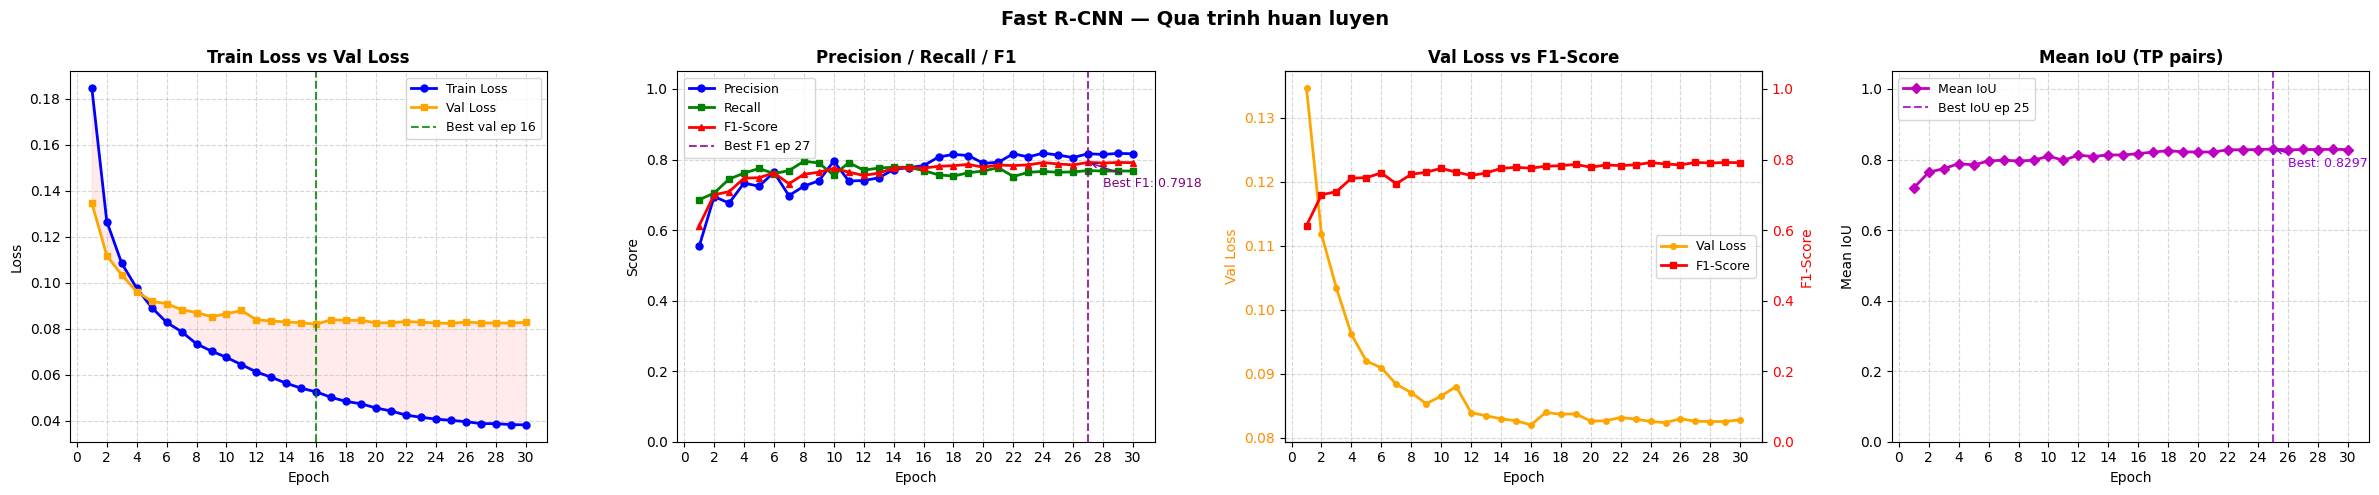

Da luu: /workspace/fast_rcnn_output/training_curve.png

 Epoch    Train    Valid  Precision   Recall       F1      IoU
     1   0.1846   0.1346     0.5537   0.6859   0.6127   0.7197
     2   0.1267   0.1118     0.6950   0.7050   0.7000   0.7643
     3   0.1085   0.1034     0.6765   0.7446   0.7089   0.7740
     4   0.0977   0.0962     0.7333   0.7614   0.7471   0.7884
     5   0.0893   0.0920     0.7242   0.7746   0.7486   0.7847
     6   0.0828   0.0910     0.7639   0.7602   0.7620   0.7960
     7   0.0788   0.0884     0.6975   0.7686   0.7313   0.7982
     8   0.0735   0.0871     0.7246   0.7950   0.7581   0.7958
     9   0.0703   0.0853     0.7396   0.7902   0.7641   0.7981
    10   0.0676   0.0865     0.7955   0.7554   0.7749   0.8094
    11   0.0645   0.0880     0.7391   0.7914   0.7643   0.7980
    12   0.0613   0.0840     0.7405   0.7698   0.7549   0.8123
    13   0.0590   0.0835     0.7480   0.7758   0.7616   0.8085
    14   0.0564   0.0830     0.7717   0.7782   0.7749   0.8132

In [12]:
csv_path = os.path.join(OUTPUT_DIR, 'training_history.csv')
df = pd.read_csv(csv_path)

best_val_epoch = df.loc[df['val_loss'].idxmin(), 'epoch']
best_f1_epoch  = df.loc[df['f1'].idxmax(),       'epoch']
best_f1_val    = df['f1'].max()
best_iou_epoch = df.loc[df['iou'].idxmax(),      'epoch']
best_iou_val   = df['iou'].max()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle('Fast R-CNN — Qua trinh huan luyen', fontsize=14, fontweight='bold')

# Bieu do 1: Train Loss vs Val Loss
ax1 = axes[0]
ax1.plot(df['epoch'], df['train_loss'], 'b-o', lw=2, ms=5, label='Train Loss')
ax1.plot(df['epoch'], df['val_loss'], 'orange', marker='s', lw=2, ms=5, label='Val Loss')
ax1.fill_between(df['epoch'], df['train_loss'], df['val_loss'], alpha=0.08, color='red')
ax1.axvline(x=best_val_epoch, color='green', ls='--', alpha=0.8,
            label=f'Best val ep {int(best_val_epoch)}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Train Loss vs Val Loss', fontweight='bold')
ax1.grid(True, ls='--', alpha=0.5); ax1.legend(fontsize=9)
ax1.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Bieu do 2: Precision / Recall / F1
ax2 = axes[1]
ax2.plot(df['epoch'], df['precision'], 'b-o', lw=2, ms=5, label='Precision')
ax2.plot(df['epoch'], df['recall'],    'g-s', lw=2, ms=5, label='Recall')
ax2.plot(df['epoch'], df['f1'],        'r-^', lw=2, ms=5, label='F1-Score')
ax2.axvline(x=best_f1_epoch, color='purple', ls='--', alpha=0.8,
            label=f'Best F1 ep {int(best_f1_epoch)}')
ax2.annotate(f'Best F1: {best_f1_val:.4f}',
             xy=(best_f1_epoch, best_f1_val),
             xytext=(best_f1_epoch + 1, best_f1_val - 0.07),
             fontsize=9, color='purple',
             arrowprops=dict(arrowstyle='->', color='purple'))
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall / F1', fontweight='bold')
ax2.set_ylim(0, 1.05); ax2.grid(True, ls='--', alpha=0.5); ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(ticker.MultipleLocator(2))

# Bieu do 3: Val Loss vs F1 (dual axis)
ax3 = axes[2]
l1, = ax3.plot(df['epoch'], df['val_loss'], 'orange', marker='o', lw=2, ms=4, label='Val Loss')
ax3.set_xlabel('Epoch'); ax3.set_ylabel('Val Loss', color='darkorange')
ax3.tick_params(axis='y', labelcolor='darkorange')
ax3b = ax3.twinx()
l2, = ax3b.plot(df['epoch'], df['f1'], 'r-s', lw=2, ms=4, label='F1-Score')
ax3b.set_ylabel('F1-Score', color='red'); ax3b.tick_params(axis='y', labelcolor='red')
ax3b.set_ylim(0, 1.05)
ax3.set_title('Val Loss vs F1-Score', fontweight='bold')
ax3.grid(True, ls='--', alpha=0.5)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax3.legend(handles=[l1, l2], loc='center right', fontsize=9)

# Bieu do 4: Mean IoU
ax4 = axes[3]
ax4.plot(df['epoch'], df['iou'], 'm-D', lw=2, ms=5, label='Mean IoU')
ax4.axvline(x=best_iou_epoch, color='darkviolet', ls='--', alpha=0.8,
            label=f'Best IoU ep {int(best_iou_epoch)}')
ax4.annotate(f'Best: {best_iou_val:.4f}',
             xy=(best_iou_epoch, best_iou_val),
             xytext=(best_iou_epoch + 1, best_iou_val - 0.05),
             fontsize=9, color='darkviolet',
             arrowprops=dict(arrowstyle='->', color='darkviolet'))
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Mean IoU')
ax4.set_title('Mean IoU (TP pairs)', fontweight='bold')
ax4.set_ylim(0, 1.05); ax4.grid(True, ls='--', alpha=0.5); ax4.legend(fontsize=9)
ax4.xaxis.set_major_locator(ticker.MultipleLocator(2))

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'training_curve.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Da luu: {save_path}')

# Bang tong ket
print(f"\n{'='*86}")
print(f"{'Epoch':>6} {'Train':>8} {'Valid':>8} "
      f"{'Precision':>10} {'Recall':>8} {'F1':>8} {'IoU':>8}")
print(f"{'='*86}")
for _, row in df.iterrows():
    marker = ' <- Best F1' if row['epoch'] == best_f1_epoch else ''
    print(f"{int(row['epoch']):>6} {row['train_loss']:>8.4f} {row['val_loss']:>8.4f} "
          f"{row['precision']:>10.4f} {row['recall']:>8.4f} {row['f1']:>8.4f} "
          f"{row['iou']:>8.4f}{marker}")
print(f"{'='*86}")

## 11. Inference — Kiểm tra trên ảnh

In [ ]:
# ---- Doi duong dan anh o day ----
IMAGE_PATH     = r'duong_dan_anh_cua_ban.jpg'
CONF_THRESHOLD = 0.5
NUM_CLASSES    = 3
CLASS_NAMES    = {1: 'with_helmet', 2: 'without_helmet', 3: 'head'}
COLORS         = {1: (0,200,0), 2: (0,0,255), 3: (255,165,0)}

# Load model
infer_model = FastRCNN(
    num_classes=NUM_CLASSES,
    min_size=640, max_size=1024,
    dropout=0.0,
    trainable_backbone_layers=0,
).to(device)
ckpt_path = os.path.join(OUTPUT_DIR, 'fast_rcnn_best.pth')
infer_model.load_state_dict(torch.load(ckpt_path, map_location=device))
infer_model.eval()
print('Model loaded:', ckpt_path)

# Load anh
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
orig_h, orig_w = img_rgb.shape[:2]

# Tinh proposals bang SS
ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
min_side = min(orig_h, orig_w); max_side = max(orig_h, orig_w)
scale    = min(640 / min_side, 1024 / max_side)
new_h, new_w = int(orig_h * scale), int(orig_w * scale)
img_resized  = cv2.resize(img_bgr, (new_w, new_h))
ss.setBaseImage(img_resized); ss.switchToSelectiveSearchFast()
rects = ss.process()[:2000]
boxes_orig = []
for (x, y, bw, bh) in rects:
    x1 = max(0, x / scale); y1 = max(0, y / scale)
    x2 = min(orig_w, (x + bw) / scale); y2 = min(orig_h, (y + bh) / scale)
    if x2 > x1 and y2 > y1:
        boxes_orig.append([x1, y1, x2, y2])
proposals_tensor = torch.tensor(boxes_orig, dtype=torch.float32).to(device)

# Inference
img_tensor = torch.from_numpy(img_rgb.transpose(2,0,1)).float() / 255.0
with torch.no_grad():
    outputs = infer_model([img_tensor.to(device)], [proposals_tensor])
output = outputs[0]

# Ve bounding box
img_draw = img_bgr.copy()
for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
    if score < CONF_THRESHOLD: continue
    x1, y1, x2, y2 = map(int, box.cpu())
    cls  = label.item()
    name = CLASS_NAMES.get(cls, f'cls{cls}')
    col  = COLORS.get(cls, (255,255,255))
    cv2.rectangle(img_draw, (x1,y1), (x2,y2), col, 2)
    cv2.putText(img_draw, f'{name} {score:.2f}', (x1, y1-6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 2)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.axis('off'); plt.title(f'Fast R-CNN Inference (conf>={CONF_THRESHOLD})')
plt.show()